## Computes travel time matrix for geodesic, walk, or drive

In [1]:
# import sys
# !{sys.executable} -m pip install osmnx

In [2]:
# extract files from zipped folder
# this will add the unzipped files to the folder
# is this the best way to do this?

# import zipfile
# with zipfile.ZipFile("../Data/grocery_stores.zip") as zip_ref:
#     zip_ref.extractall()
#     print("Extracted files:")
#     for file in zip_ref.namelist():
#         print(file)

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import json
import urllib.request
import geopy.distance
from shapely.geometry import Point, LineString, Polygon
from shapely.geometry import MultiPoint
import networkx as nx
import osmnx as ox
import osmnx.routing as routing

In [3]:
# loading in files
# datadir = "../Data"
sites = gpd.read_file("Grocery Stores/geo_export_872fcb6c-fbde-4264-ae77-8858a604ed0e.shp")

<Axes: >

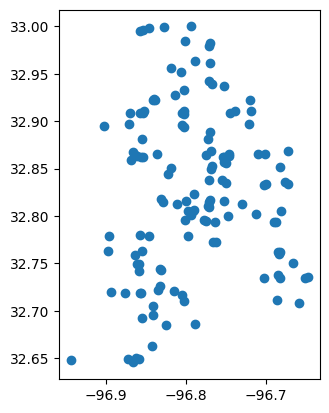

In [3]:
sites.plot()

In [5]:
# for testing purposes
# extracts a small sample of grocery stores in a specific area

# use this bbox as input to comp_mat function
bbox = [-96.808, 32.780, -96.788, 32.807]

# area that contains five grocery stores in dallas
four_tuples = [
    (-96.808, 32.780),
    (-96.808, 32.807),
    (-96.788, 32.807),
    (-96.788, 32.780)]

geo_area = Polygon(four_tuples)

# extracts these five grocery stores from the set of all grocery stores
sites_select = sites[sites['city'] == 'Dallas']
sites_select['intersects'] = sites_select.within(geo_area)
five_sites = sites_select[sites_select['intersects'] == True]
five_sites = five_sites.reset_index()
five_sites = five_sites.drop('index', axis = 1)

In [6]:
# define functions for geodesic

# compute geodesic distance between two given points a and b
def get_dist(a, b):
    origin = str(a.y)+','+str(a.x)
    destination = str(b.y)+','+str(b.x)
    dist = geopy.distance.geodesic(origin, destination)
    return dist.meters

# compute geodesic distance (in meters) between every pair in a set of points
def comp_geod_dist_mat(sites):
    dists = np.zeros((len(sites), len(sites)))
    for i, a in sites.iterrows():
        for j, b in sites.iterrows():
            if i != j:
                dists[i,j] = get_dist(a.geometry,b.geometry)
    return dists

# converts units of a distance matrix from meters to walking time using an average walk speed 
def sec_from_mtr(dists_mtr):
    walk_speed = 1.42 # meters/sec
    dists_sec = dists_mtr / walk_speed
    return dists_sec

In [7]:
# define functions for walk

# load in open street maps
def load_map(network_type, 
             city = "Dallas County",
             use_bbox = False,
             bbox = [-97.1, 32.5, -96.45, 33.1]):
    # use default bbox to include the southern piece of collin county, if desired
    if use_bbox:
        G = ox.graph_from_bbox(bbox, network_type = network_type, simplify = False)
    else: 
        place = city
        G = ox.graph_from_place(place, network_type = network_type, simplify = False)
    return G

def build_pairs_list(nodes, dist_is_symmetric):
    pairs_list = []
    for i in range(len(nodes)):
        for j in range(i+1,len(nodes)):
            pairs_list.append((i,j))

        if not dist_is_symmetric:
            for j in range(0,i):
                pairs_list.append((i,j))
    return pairs_list

    
def comp_walk_dist_mat(nodes, G, dist_is_symmetric):
    # list pairs of indices for distance computation
    # allows individual computations to be farmed out in arbitrary order if parallel processing
    pairs_list = build_pairs_list(nodes, dist_is_symmetric)

    # base matrix for distance calculations
    dists = np.zeros((len(nodes), len(nodes)))

    # compute shortest path length between each node
    # put dist(a,b) as entry (a,b) in distances matrix
    # if dist(a,b) = dist(b,a) then put dist(a,b) as entry in distances matrix

    for p1, p2 in pairs_list:
        d = nx.shortest_path_length(G, nodes[p1], nodes[p2], weight='length')
        dists[p1, p2] = d

        if dist_is_symmetric:
            dists[p2, p1] = d

    return dists


In [8]:
# define functions for drive

# calculates the shortest travel time between two given points
def comp_drive_path(p1, p2, nodes, G):
    path = routing.shortest_path(G, nodes[p1], nodes[p2], weight = "travel_time")
    gdf_edges = routing.route_to_gdf(G, path, weight = "travel_time")
    return gdf_edges

# computes drive time for a given path
def comp_drive_time(gdf_edges):
    return gdf_edges["travel_time"].sum()

# ccomputes distance of a given path
def comp_drive_dist(gdf_edges):
    return gdf_edges["length"].sum()

# computes matrix of driving times between points
def comp_drive_time_mat(nodes, G, dist_is_symmetric):
    # list pairs of indices for distance computation
    # allows individual computations to be farmed out in arbitrary order if parallel processing
    pairs_list = build_pairs_list(nodes, dist_is_symmetric)

    # base matrix for distance calculations
    dists = np.zeros((len(nodes), len(nodes)))

    # add speed limit information to graph G
    G = routing.add_edge_speeds(G, agg = np.mean)
    G = routing.add_edge_travel_times(G)
    
    # compute shortest path length between each node
    # put dist(a,b) as entry (a,b) in distances matrix
    # if dist(a,b) = dist(b,a) then put dist(a,b) as entry in distances matrix
    for p1, p2 in pairs_list:
        gdf_edges = comp_drive_path(p1, p2, nodes, G)
        d = comp_drive_time(gdf_edges)
        dists[p1, p2] = d

        if dist_is_symmetric:
            dists[p2, p1] = d

    return dists

# computes matrix of driving distances between points
def comp_drive_dist_mat(nodes, G, dist_is_symmetric):
    # list pairs of indices for distance computation
    # allows individual computations to be farmed out in arbitrary order if parallel processing
    pairs_list = build_pairs_list(nodes, dist_is_symmetric)

    # base matrix for distance calculations
    dists = np.zeros((len(nodes), len(nodes)))

    # add speed limit information to graph G
    G = routing.add_edge_speeds(G, agg = np.mean)
    G = routing.add_edge_travel_times(G)
    
    # compute shortest path length between each node
    # put dist(a,b) as entry (a,b) in distances matrix
    # if dist(a,b) = dist(b,a) then put dist(a,b) as entry in distances matrix
    for p1, p2 in pairs_list:
        gdf_edges = comp_drive_path(p1, p2, nodes, G)
        d = comp_drive_dist(gdf_edges)
        dists[p1, p2] = d

        if dist_is_symmetric:
            dists[p2, p1] = d

    return dists

In [9]:
# G = load_map(network_type = "drive", 
#              city = "Dallas County",
#              use_bbox = True,
#              bbox = [-96.808, 32.780, -96.788, 32.807])

# nodes = ox.distance.nearest_nodes(G, five_sites["geometry"].x, five_sites["geometry"].y)

# comp_drive_dist_mat(nodes, G, dist_is_symmetric = False)

In [10]:
# combined function to compute full matrix for a specific metric
def comp_mat(sites, 
             network_type = "walk", 
             city = "Dallas County",
             use_bbox = False, 
             dist_is_symmetric = False,
             bbox = [-97.1, 32.5, -96.45, 33.1]):
    
    # determins if given distance measure is symmetric
    if network_type == "geodesic" or network_type == "walk":
        dist_is_symmetric = True

    if network_type == "geodesic":
        dists_mtr = comp_geod_dist_mat(sites)
        dists = min_from_mtr(dists_mtr)

    elif network_type == "walk":
        # load street network
        # use bbox to include the southern piece of collin county, if desired
        G = load_map(network_type, city, use_bbox, bbox)
        
        # maps sites onto nearest nodes on street network
        nodes = ox.distance.nearest_nodes(G, sites["geometry"].x, sites["geometry"].y)

        # computes distance between all pairs of distinct sites
        dists_mtr = comp_walk_dist_mat(nodes, G, dist_is_symmetric)
        dists = min_from_mtr(dists_mtr)
            
    elif network_type == "drive":
        # load street network
        # use bbox to include the southern piece of collin county, if desired
        G = load_map(network_type, city, use_bbox, bbox)
        
        # maps sites onto nearest nodes on street network
        nodes = ox.distance.nearest_nodes(G, sites["geometry"].x, sites["geometry"].y)
        dists_sec = comp_drive_time_mat(nodes, G, dist_is_symmetric)
        dists = dists_sec / 60
        
    return dists

In [11]:
# compute distance and time matrices for all geodesic, walk, and drive
# returns npz file with each matrix as a column

def comp_all_mats(sites, 
             city = "Dallas County",
             use_bbox = False, 
             dist_is_symmetric = False,
             bbox = [-97.1, 32.5, -96.45, 33.1]):

    # geodesic
    walk_speed = 1.42
    dists_geod = comp_geod_dist_mat(sites)
    time_geod = sec_from_mtr(dists_geod)
    print("finished geodesic matrix")
    np.savez("grocery_geod_mat", walk_speed = walk_speed, 
             dists_geod = dists_geod, 
             time_geod = time_geod)

    
    # walk
    G_walk = load_map(network_type = "walk", city = city, use_bbox = use_bbox, bbox = bbox)
    nodes_walk = ox.distance.nearest_nodes(G_walk, sites["geometry"].x, sites["geometry"].y)

    dists_walk = comp_walk_dist_mat(nodes_walk, G_walk, dist_is_symmetric)
    time_walk = sec_from_mtr(dists_walk)
    print("finished walk matrix")
    np.savez("grocery_walk_mat", walk_speed = walk_speed, 
             dists_walk = dists_walk, 
             time_walk = time_walk)

    
    # drive
    G_drive = load_map(network_type = "drive", city = city, use_bbox = use_bbox, bbox = bbox)
    nodes_drive = ox.distance.nearest_nodes(G_drive, sites["geometry"].x, sites["geometry"].y)

    # list pairs of indices for distance computation
    # allows individual computations to be farmed out in arbitrary order if parallel processing
    pairs_list = build_pairs_list(nodes_drive, dist_is_symmetric)

    # base matrix for distance calculations
    dists_drive = np.zeros((len(nodes_drive), len(nodes_drive)))
    time_drive = np.zeros((len(nodes_drive), len(nodes_drive)))

    # add speed limit information to graph G
    G_drive = routing.add_edge_speeds(G_drive, agg = np.mean)
    G_drive = routing.add_edge_travel_times(G_drive)
    
    # compute shortest path length between each node
    # put dist(a,b) as entry (a,b) in distances matrix
    # if dist(a,b) = dist(b,a) then put dist(a,b) as entry in distances matrix
    for p1, p2 in pairs_list:
        gdf_edges = comp_drive_path(p1, p2, nodes_drive, G_drive)
        d_dist = comp_drive_dist(gdf_edges)
        d_time = comp_drive_time(gdf_edges)
        dists_drive[p1, p2] = d_dist
        time_drive[p1, p2] = d_time

        if dist_is_symmetric:
            dists_drive[p2, p1] = d_dist
            time_drive[p2, p1] = d_time
            
    print("finished drive matrix")
    np.savez("grocery_drive_mat",
             dists_drive = dists_drive,
             time_drive = time_drive)
    

In [12]:
# tests relevant functions on small sample bbox

# dists = comp_mat(sites_select_inner, 
#              network_type = "drive", 
#              city = "Dallas County",
#              use_bbox = True,
#              bbox = [-96.808, 32.780, -96.788, 32.807])

# comp_all_mats(five_sites, 
#              city = "Dallas County",
#              use_bbox = True,
#              bbox = [-96.808, 32.780, -96.788, 32.807])

finished geodesic matrix
finished walk matrix
finished drive matrix


In [13]:
# computes all matrices for full sample set
# comp_all_mats(sites, 
#              city = "Dallas County",
#              use_bbox = False,
#              dist_is_symmetric = False,
#              bbox = [-97.1, 32.5, -96.45, 33.1])